# Importando bibliotecas

In [1]:
import pandas as pd
import numpy as np

In [2]:
from gensim.models import Word2Vec

model = Word2Vec.load("data/models/node2vec_01.model")

In [3]:
nodes = list(model.wv.index_to_key)
embeddings = np.array([model.wv[node] for node in nodes])

In [4]:
import hdbscan
from sklearn.preprocessing import normalize

embeddings_norm = normalize(embeddings)
clusterer = hdbscan.HDBSCAN(metric='euclidean')
labels = clusterer.fit_predict(embeddings_norm)

cluster_df = pd.DataFrame({
    "Alert Type": nodes,
    "Cluster": labels
})

cluster_df

,Alert Type,Cluster
0,CONNECTIVITY_PORT_STATE_OUTBOUND_USAGE,4
1,CONNECTIVITY_PORT_STATE_INBOUND_USAGE,4
2,MYSQL_SGBD_INDEX_DETAILS,-1
3,KAFKA_ACTIVE_CONTROLLERS,3
4,OPENSHIFT_ETCD_ELECTIONS_PER_DAY,0
...,...,...
162,3SCALE_CLUSTER_UPSTREAM_COUNT,6
163,MANAGEMENT_BOARD_POWER_SUPPLY_UNIT_READING_AMPS,-1
164,JVM_MEMORY_HEAP,-1
165,KAFKA_LATENCY_FETCH,-1


In [59]:
# cluster_df.pivot(columns='Cluster', values='Alert Type')
cluster_df['n'] = cluster_df.groupby('Cluster').cumcount()
alerts_by_cluster = cluster_df.pivot(index='n', columns='Cluster', values='Alert Type')

alerts_by_cluster.index.name = None
alerts_by_cluster = alerts_by_cluster.reindex(sorted(alerts_by_cluster.columns), axis=1)
alerts_by_cluster = alerts_by_cluster.fillna("")

alerts_by_cluster.to_excel("data/results/alerts_by_cluster_v1.xlsx", index=False)

alerts_by_cluster

Cluster,-1,0,1,2,3,4,5,6,7
0,MYSQL_SGBD_INDEX_DETAILS,OPENSHIFT_ETCD_ELECTIONS_PER_DAY,SPARK_JVM_GARBAGE_COLLECTOR_YOUNG,STORAGE_VOLUME_STATUS_KBYTES_PER_SECOND_MAX,KAFKA_ACTIVE_CONTROLLERS,CONNECTIVITY_PORT_STATE_OUTBOUND_USAGE,HOST_UNREACHABLE,ID-2127,OPENSHIFT_CLUSTER_PVC
1,OPENSHIFT_CLUSTER_MISSING_METRICS,OPENSHIFT_CLUSTER_NODE_LOAD_AVG_1_MIN_PERCENT,SPARK_DAG_SCHEDULER_ALL_JOBS,STORAGE_VOLUME_STATUS_IDLE_PERCENT_AVG,KAFKA_BYTES_OUT_PER_TOPIC,CONNECTIVITY_PORT_STATE_INBOUND_USAGE,HARDWARE_INTEGRITY_VIRTUAL_MACHINES_VM_GUEST_S...,AIRFLOW_DAG_RUN_DURATION_FAILED_COUNT,OPENSHIFT_CLUSTER_DEPLOYMENT_MEMORY_LIMITS_PER...
2,CACHE_HIT_INDEX,OPENSHIFT_CLUSTER_NODE_MEMORY_PERCENT,SPARK_LIVE_LISTENER_BUS_NUMBER_OF_APP,STORAGE_VOLUME_STATUS_IOSZ_CUR,KAFKA_BYTES_OUT_PER_BROKER,CONNECTIVITY_PORT_STATE_SFP_INFO,HARDWARE_INTEGRITY_VIRTUAL_MACHINES_VM_STATE,DRUID_SERVICE_USAGE,OPENSHIFT_CLUSTER_RESOURCE_QUOTA
3,3SCALE_PRODUCT_UPSTREAM_COUNT,OPENSHIFT_CLUSTER_NODE_CPU_PERCENT,SPARK_CODE_GENERATOR_TIME_COMPILATION,STORAGE_VOLUME_STATUS_IDLE_PERCENT_CUR,KAFKA_BYTES_IN_PER_TOPIC,CONNECTIVITY_PORT_STATE_INFO,SOFTWARE_SERVICE_STATUS_INFO,DRUID_REPLICATION_SIZE,OPENSHIFT_CLUSTER_NAMESPACE_CPU_LIMIT_PERCENT
4,TEMPLATE_CUSTOM,OPENSHIFT_CLUSTER_NODE_FILE_SYSTEM_PERCENT,SPARK_DAG_SCHEDULER_MESSAGE_PROCESSING_NUMBER,STORAGE_LINK_STATISTICS_XCB_SENT_PER_SECOND_CUR,KAFKA_BROKER_NETWORK_THROUGHPUT_IN,CONNECTIVITY_PORT_STATE_SFP_AMPS,SYSTEM_LOAD_AVERAGE_LAST_1_MIN,REDIS_MEMORY_DATA_SET,OPENSHIFT_CLUSTER_NAMESPACE_MEMORY_LIMIT_PERCENT
5,MONGODB_CACHE_HIT,OPENSHIFT_CLUSTER_NODE_LOAD_AVG_5_MIN_PERCENT,SPARK_LIVE_LISTENER_BUS_PROCESSING_EVENTS,STORAGE_VOLUME_STATUS_IO_PER_SECOND_MAX,KAFKA_BYTES_IN_PER_BROKER,HARDWARE_INTEGRITY_FAN_STATUS_STATUS,MANAGEMENT_BOARD_TEMPERATURE_READING,MANAGEMENT_BOARD_POWER_SUPPLY_PRESENT,OPENSHIFT_CLUSTER_DEPLOYMENT_CPU_LIMITS_PERCENT
6,MONGODB_DATABASE_SIZE,,SPARK_LIVE_LISTENER_BUS_NUMBER_OF_EVENTS,STORAGE_VOLUME_STATUS_SVT_CUR,KAFKA_MESSAGES_IN_PER_BROKER,,CAPACITY_CPU_USAGE_IDLE_PERCENT,ID-2103,
7,AMS_5520_CLUSTER_NEW_SERVER,,SPARK_CODE_GENERATOR_CLASS_SIZE,STORAGE_VOLUME_STATUS_IOSZ_AVG,KAFKA_ONLINE_PARTITIONS,,MANAGEMENT_BOARD_PHYSICAL_DISKS_STATUS,ID-6008,
8,HARDWARE_INTEGRITY_NETWORK_INFORMATION_LINK_ST...,,SPARK_HIVE_EXTERNAL_CATALOG_FILE_DISCOVERED,STORAGE_VOLUME_STATUS_IO_PER_SECOND_CUR,KAFKA_JVM_MEMORY_USED,,CAPACITY_DISK_FREE_USED_PERCENT,ID-2130,
9,KAFKA_MISSING_METRICS,,SPARK_JVM_GARBAGE_COLLECTOR_OLD,STORAGE_VOLUME_STATUS_KBYTES_PER_SECOND_CUR,KAFKA_BROKER_NETWORK_THROUGHPUT_OUT,,MANAGEMENT_BOARD_NETWORK_PORT_STATUS_CONNECTIO...,ID-2106,


# Visualização

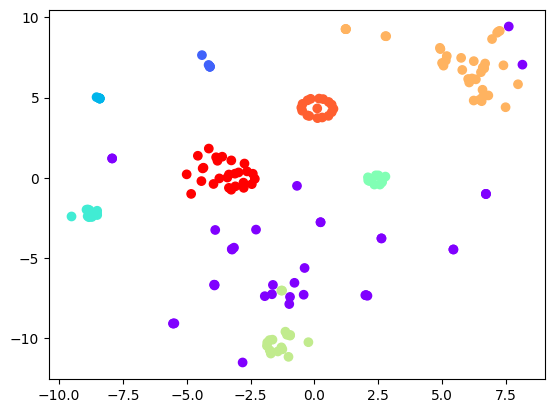

In [53]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=100)
reduced = tsne.fit_transform(embeddings)

plt.scatter(reduced[:,0], reduced[:,1], c=labels, cmap='rainbow')
plt.show()